# Numerical methods for Physics and Astrophysics:  Lab exercises

This notebook contains solutions to the problem set found [here](https://home.icts.res.in/~ajith/Teaching_files/Lab.pdf).

## Table of Contents:
* [Ex 1A: Finite Differencing, Convergences, Error Estimates](#sec1)
* [Ex 1B: Richardson Extrapolation](#sec2)
* [Ex 2: ODEs - Calculation of gravitational waves from inspiralling compact binaries](#sec3)
* [Ex 3: ODEs - Structure of a relativistic, spherically symmetric star](#sec4)
* [Ex 4A: Non-linear ODE with chaotic behavior: Lorenz equations](#sec5)
* [Ex 4B: Stochastic ODE: Langevin equation](#sec6)
* [Ex 5: Two-point boundary value problems: The shooting method](#sec7)
* [Ex 6: Partial Differential Equations](#sec8)
* [Ex 7A: Fast Fourier transform (FFT)](#sec9)
* [Ex 7B: Power spectrum estimation using FFT](#sec10)
* [Ex 7C: Time-frequency signal detection methods](#sec11)
* [Ex 7D: Computing correlations using FFT: Matched filtering](#sec12)

## Ex 1A: Finite Differencing, Convergences, Error Estimates

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt


def finite_diff(func, x, h):
    """
    Function to find derivatives using forward, backward and central finte-differencing methods
    Args:
        func: function whose derivative is to be computated
        x_min: lower bound of the input range
        x_max: upper bound of the ouput range
        h: step size 
    Returns:
        (x, for_diff, back_diff, cen_diff): tuple consisting of an numpy array of points in the input range 
        and numpy arrays of derivates calculated using dfferent methods.
    """
    for_diff = (func(x+h) - func(x))/h
    back_diff = (func(x) - func(x-h))/h
    cen_diff = (func(x+h) - func(x-h))/(2*h)
    return (for_diff, back_diff, cen_diff)

#input functions
def f(x):
    return np.exp(x) * np.sin(x)
def dvt_f(x): 
    return np.exp(x)*(np.sin(x)+np.cos(x))

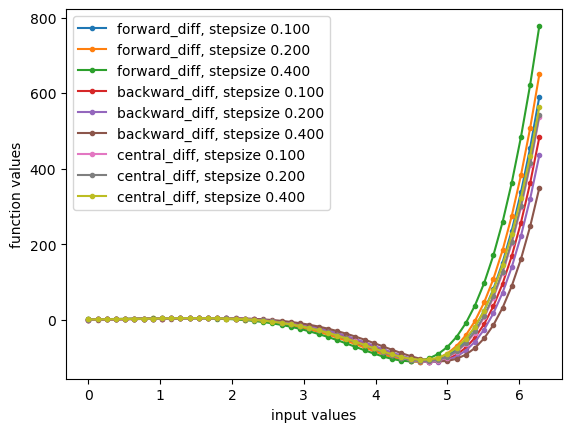

In [2]:
#problem 1
h = 0.1
x = np.linspace(0, 2 * math.pi)
data1h = finite_diff(f,x, h)
data2h = finite_diff(f, x, 2*h)
data4h = finite_diff(f, x, 4*h)

data = [data1h,data2h, data4h]
methodName = ['forward_diff', 'backward_diff', 'central_diff']

for j in range(3):
    for i in range(len(data)):
        plt.plot(x,data[i][j], '.-', label = methodName[j] + ', stepsize {:.3f}'.format((2**i)*h))
plt.xlabel("input values")
plt.ylabel("function values")
plt.legend()
plt.show()

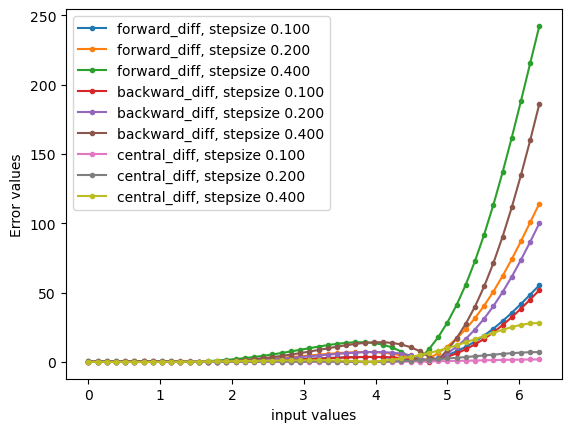

In [3]:
#problem2
error =[]
for i in range(len(data)):
    errhs = []
    for j in range(3):
        errArray = np.abs(data[i][j]-dvt_f(x))
        errhs.append(errArray)
    error.append(errhs)

for j in range(3):
    for i in range(3):
        plt.plot(x,error[i][j], '.-', label = methodName[j] + ', stepsize {:.3f}'.format((2**i)*h))
plt.xlabel("input values")
plt.ylabel("Error values")
plt.legend()
plt.show()

In [4]:
#estimating order of convergence: method 1
b = 5

h_arr = np.linspace(0.001, 0.1, 10)
logh = np.log(h_arr)
dvt_finite = finite_diff(f, b, h_arr)
log_error =[]

for i in range(3):
    error = np.abs(dvt_finite[i] - dvt_f(b))
    log_error.append(np.log(error))
    
order_forwd = round(np.polyfit(logh,log_error[0],1)[0])
order_backwd = round(np.polyfit(logh,log_error[1],1)[0])
order_cent = round(np.polyfit(logh,log_error[2],1)[0])

print("Order of convergence for Forward, Backward and Central difference methods are {}, {}, & {} respectively".format(order_forwd, order_backwd, order_cent))


Order of convergence for Forward, Backward and Central difference methods are 1, 1, & 2 respectively


In [5]:
#estimating order of convergence: method 2
nfor, nback, ncen = [],[],[]

n_for = np.log2((data4h[0]-data2h[0])/(data2h[0]-data1h[0]))
n_back = np.log2((data4h[1]-data2h[1])/(data2h[1]-data1h[1]))
n_cen = np.log2((data4h[2]-data2h[2])/(data2h[2]-data1h[2]))

order_for = round(np.nanmean(n_for))
order_back = round(np.nanmean(n_back))
order_cen = round(np.nanmean(n_cen))

print("Order of convergence for forward-differencing method is {}".format(order_for))
print("Order of convergence for backward-differencing method is {}".format(order_back))
print("Order of convergence for central-differencing method is {}".format(order_cen))

Order of convergence for forward-differencing method is 1
Order of convergence for backward-differencing method is 1
Order of convergence for central-differencing method is 2


/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/3964037407.py:4: RuntimeWarning: invalid value encountered in log2
  n_for = np.log2((data4h[0]-data2h[0])/(data2h[0]-data1h[0]))
/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/3964037407.py:5: RuntimeWarning: invalid value encountered in log2
  n_back = np.log2((data4h[1]-data2h[1])/(data2h[1]-data1h[1]))
/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/3964037407.py:6: RuntimeWarning: invalid value encountered in log2
  n_cen = np.log2((data4h[2]-data2h[2])/(data2h[2]-data1h[2]))


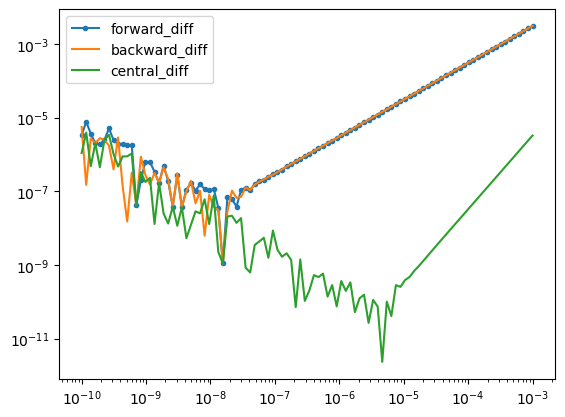

In [6]:
#problem3
hArray = np.geomspace(1e-10, 0.001, 100)
a = 2

dvt_finite = finite_diff(f, a, hArray)
error_h =[]

for i in range(3):
    error = np.abs(dvt_finite[i] - dvt_f(a))
    error_h.append(error)

symbol = ['.-', '-', '-']

for i in range(3):
    plt.plot(hArray, error_h[i], symbol[i], label = methodName[i])

plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()


<a id="sec2"></a>
## Ex 1B: Richardson Extrapolation

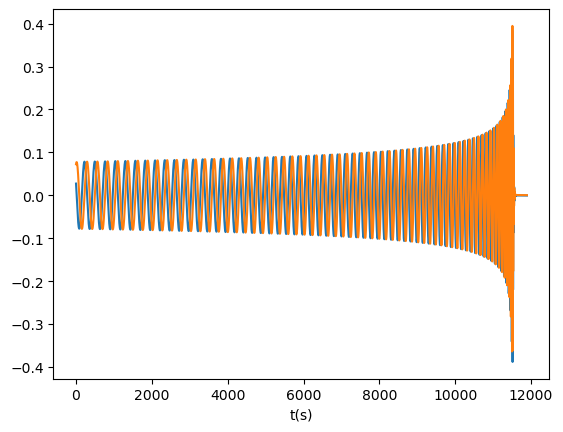

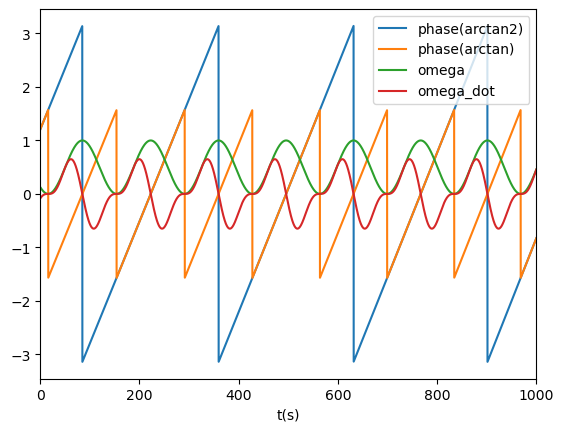

In [7]:
import numpy as np 
import matplotlib.pyplot as plt

def finite_doublediff(func, x, h):
    cen_diff = (func(x+h) - 2* func(x) + func(x-h))/(h**2)
    return cen_diff

#Loading the data
t, h_plus, h_cross = np.loadtxt('data/nr_data', skiprows=1, unpack = True)
phi = np.arctan2(h_cross,h_plus)
phi2 = np.arctan(h_cross/h_plus)

''' Note: The data has time interval = 0.25s. So, if we want to calculate the derivative using 
    euler method directly from the dataset, the least possible stepsize will be 0.25 which
    is not ideal. Hence, we'll use the function we defined in previous problem instead.'''

omega = finite_diff(np.arctan, h_cross/h_plus, 0.01)[2]
omega_dot = finite_doublediff(np.arctan, h_cross/h_plus, 0.01)

plt.plot(t, h_plus)
plt.plot(t, h_cross)
# plt.xlim(11200, 11750)
plt.xlabel('t(s)')
plt.show()

plt.plot(t, phi, label = 'phase(arctan2)')
plt.plot(t, phi2, label = 'phase(arctan)')
plt.plot(t, omega, label = 'omega')
plt.plot(t, omega_dot, label = 'omega_dot')
plt.xlabel('t(s)')
plt.xlim(0, 1000)
plt.legend()
plt.show()

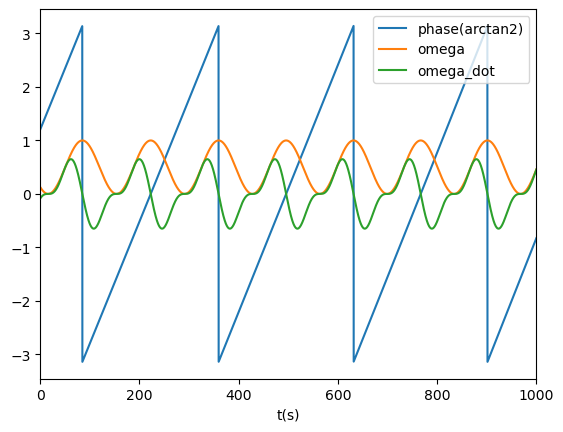

In [8]:
'''The following evaluation of omega accounts for non-differentiable points 
   and uses the "four quadrant” arctan while evaluating phi'''

def derivative_arctan2(x1, x2, h):
    f2 = np.arctan2(x1+ x2*h, x2)
    f1 = np.arctan2(x1 - x2*h, x2)
    res = (f2-f1)/(2*h)
    res = np.where(abs(res - np.mean(res)) < 10 * np.std(res), res, np.nan)
    return res

def doubledvt_arctan2(x1, x2, h):
    f0 = np.arctan2(x1, x2)
    f2 = np.arctan2(x1+ x2*h, x2)
    f1 = np.arctan2(x1 - x2*h, x2)
    res = (f2 - 2*f0 + f1)/(h**2)
    res = np.where(abs(res - np.mean(res)) < 10 * np.std(res), res, np.nan)
    return res


plt.plot(t, phi, label = 'phase(arctan2)')
plt.plot(t, omega, label = 'omega')
plt.plot(t, omega_dot, label = 'omega_dot')
plt.xlim(0, 1000)
plt.xlabel('t(s)')
plt.legend()
plt.show()

In [9]:
#problem2: estimationg order of convergence
h = 0.01

omega1 = finite_diff(np.arctan, h_cross/h_plus, h)[2]
omega2 = finite_diff(np.arctan, h_cross/h_plus, 2*h)[2]
omega4 = finite_diff(np.arctan, h_cross/h_plus, 4*h)[2]

omega_dot1 = finite_doublediff(np.arctan, h_cross/h_plus, h)
omega_dot2 = finite_doublediff(np.arctan, h_cross/h_plus, 2*h)
omega_dot4 = finite_doublediff(np.arctan, h_cross/h_plus, 4*h)


order1 = np.log2((omega4-omega2)/(omega2-omega1))
order2 = np.log2((omega_dot4-omega_dot2)/(omega_dot2-omega_dot1))

order1 = order1[~np.isinf(order1)]
order2 = order2[~np.isinf(order2)]

order_omega = round(np.nanmean(order1))
order_omegadot = round(np.nanmean(order2))

print("order of convergence of omega and omega dot are {} and {} respectively".format(order_omega, order_omegadot))

order of convergence of omega and omega dot are 2 and 2 respectively


/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/2071164053.py:13: RuntimeWarning: divide by zero encountered in divide
  order1 = np.log2((omega4-omega2)/(omega2-omega1))
/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/2071164053.py:13: RuntimeWarning: invalid value encountered in divide
  order1 = np.log2((omega4-omega2)/(omega2-omega1))
/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/2071164053.py:13: RuntimeWarning: divide by zero encountered in log2
  order1 = np.log2((omega4-omega2)/(omega2-omega1))
/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/2071164053.py:13: RuntimeWarning: invalid value encountered in log2
  order1 = np.log2((omega4-omega2)/(omega2-omega1))
/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/2071164053.py:14: RuntimeWarning: divide by zero encountered in divide
  order2 = np.log2((omega_dot4-omega_dot2)/(omega_dot2-omega_dot1))
/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/i

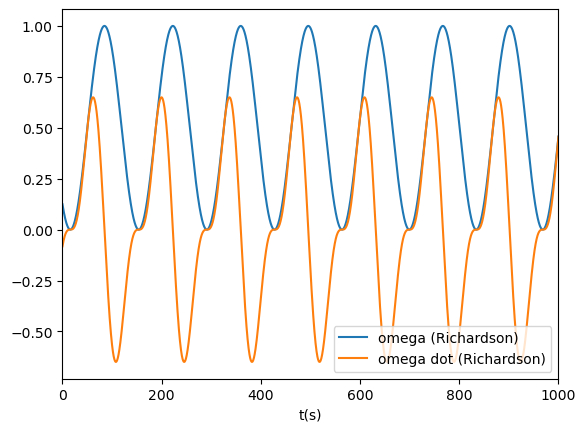

In [10]:
#Richardson Extrapolation

def extrapolate(k, f1h, f2h):
    explt = ((2**k) * f1h - f2h)/(2**k - 1)
    return explt

omega_nextorder = extrapolate(order_omega, omega1, omega2)
omegadot_nextorder = extrapolate(order_omegadot, omega_dot1, omega_dot2)

plt.plot(t, omega_nextorder, label = 'omega (Richardson)')
plt.plot(t, omegadot_nextorder, label = 'omega dot (Richardson)')
plt.xlabel('t(s)')
plt.xlim(0,1000)
plt.legend()
plt.show()


<a id="sec3"></a>
## Ex 2: ODEs - Calculation of gravitational waves from inspiralling compact binaries

In [11]:
from scipy.integrate import odeint, ode
import matplotlib.pyplot as plt
import numpy as np 

def inspiral_vphi(t, y, m, mu):
    ''' 
    Function to be used by odeint
    '''
    v, phi = y
    dv_dt = (32/5) * (mu/m**2) * (v**9)
    dphi_dt = (v**3)/m 
    dydt = [dv_dt, dphi_dt]
    return dydt

#constants
G = 6.67e-11
c = 3e8
Mo = 1.989e30 * G/(c**3) #converting to geometric units

#parameters
m1 = m2 = 5*Mo
m = m1 + m2
mu = m1*m2/m

#intial conditions
v0 =  0.3
phi0 = 0
y0 = [v0, phi0]

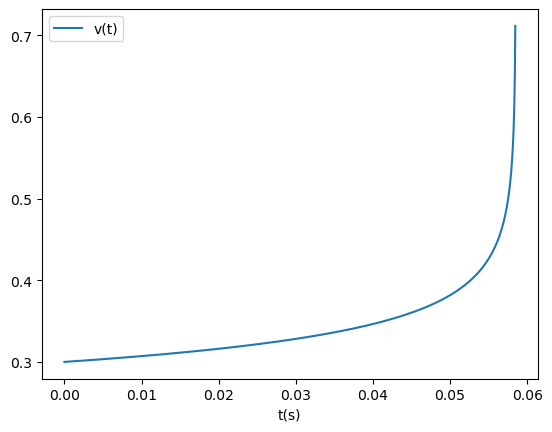

<function matplotlib.pyplot.show(close=None, block=None)>

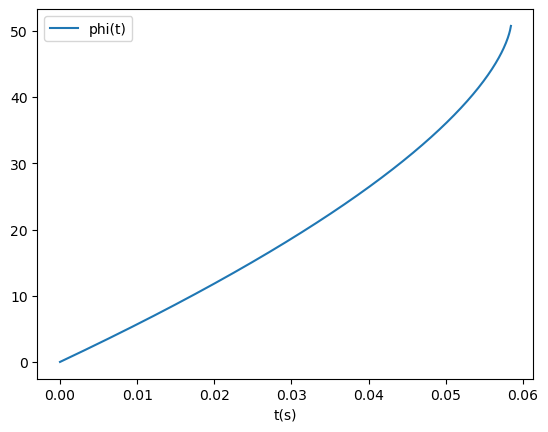

In [12]:
#problem1
tmax = 5*m**2/(256*mu*v0**8) #formula for time at the merger
N = 1000
t = np.linspace(0,tmax-tmax/N,N)

sol = odeint(inspiral_vphi, y0, t, args= (m, mu), tfirst= True)
vt = sol[:,0]
phi_t = sol[:, 1]

plt.plot(t, vt, label = 'v(t)')
plt.xlabel('t(s)')
plt.legend()
plt.show()

plt.plot(t, phi_t, '-', label = 'phi(t)')
plt.legend()
plt.xlabel('t(s)')
plt.show

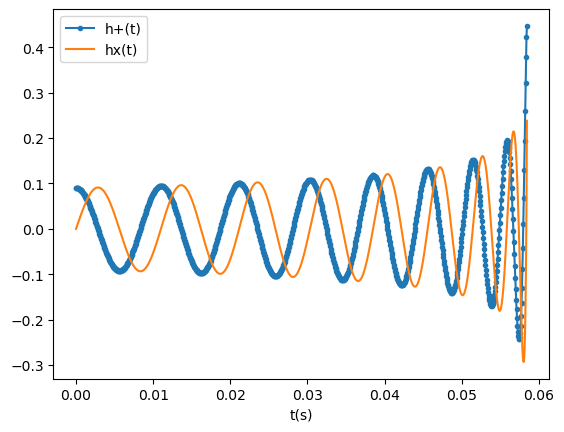

In [13]:
#problem 2

A_t = (4*mu/m) * (vt**2)
hp = A_t * np.cos(phi_t)
hc = A_t * np.sin(phi_t)

plt.plot(t, hp, '.-', label = 'h+(t)')
plt.plot(t, hc, label = 'hx(t)')
plt.xlabel('t(s)')
plt.legend()
plt.show()

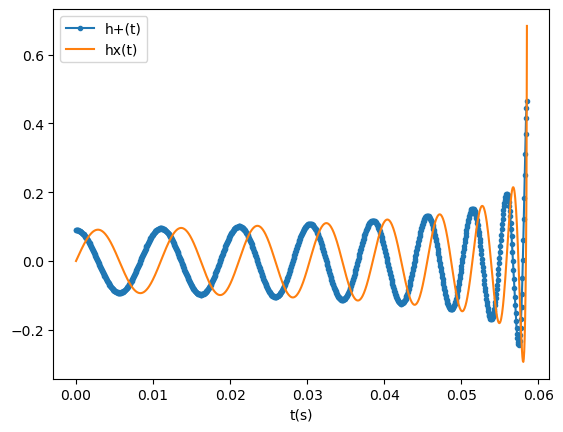

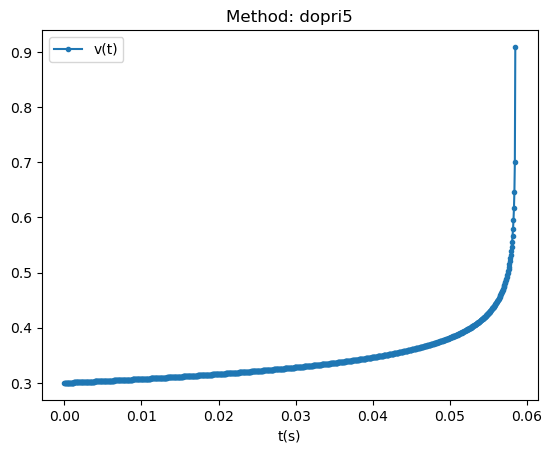

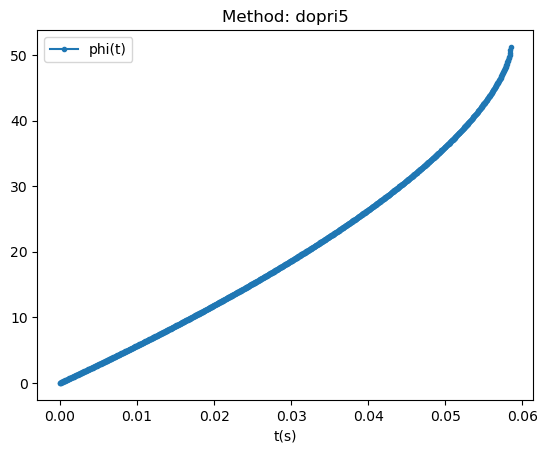

In [14]:
#problem 3
from scipy.integrate import ode

N = 1000
t1 = 0.0585
t = np.linspace(0,t1,N)
sol2 = np.empty((N, 2))
sol2[0] = y0 #add intial value to solution array
#creating ode instance and intializing 
solver = ode(inspiral_vphi)
solver.set_integrator('dopri5')
solver.set_f_params(m, mu)
solver.set_initial_value(y0)

# Repeatedly call the `integrate` method to advance the 
# solution to time t[k], and save the solution in sol2[k].
k = 1
while solver.successful() and solver.t < t1:
    solver.integrate(t[k])
    sol2[k] = solver.y
    k += 1

vt2 = sol2[:,0]
phi2 = sol2[:,1]
At2 = (4*mu/m) * (vt2**2)
hp2 = At2 * np.cos(phi2)
hc2 = At2 * np.sin(phi2)

# Plotting the results.
plt.plot(t, hp2, '.-', label = 'h+(t)')
plt.plot(t, hc2, label = 'hx(t)')
plt.xlabel('t(s)')
plt.legend()
plt.show()

plt.plot(t, vt2, '.-', label='v(t)')
plt.xlabel('t(s)')
plt.title("Method: dopri5")
plt.legend()
plt.show()

plt.plot(t, phi2,'.-', label='phi(t)')
plt.xlabel('t(s)')
plt.title("Method: dopri5")
plt.legend()
plt.show()

<a id="sec4"></a>
## Ex 3: ODEs - Structure of a Relativistic, Spherically Symmetric Star

In [15]:
import numpy as np 
import math

#global params
G = 6.67e-11
c = 3e+8

def tov_equations(r, y, K , gamma):
    
    ''' Tolman, Oppenheimer and Volkoff (TOV) equations
    '''

    m_r, p_r, phi_r = y
    rho_r = (p_r/K)**(1.0/gamma)
    
    dmdr = 4.0 * math.pi * (r**2) * rho_r

    a1 = -G*(rho_r + p_r/(c**2.0) )/(r**2)
    a2 = m_r + 4.0 * math.pi * (r**3) * p_r/(c**2)
    a3 = 1.0 - 2.0*G*m_r/(r * (c**2))
    dpdr = a1 * a2/a3

    b1 = G*m_r + 4.0*math.pi*G*(r**3)*p_r/(c**2)
    b2 = (c*r)**2 - 2.0 * G * m_r * r
    dphidr = b1/b2

    dydr = [dmdr, dpdr, dphidr]
    return dydr


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1516651730486D+05   r2 =  0.5569991535915D-12
(m*,r*) = (1.201E+30 kg,15.12 km)

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1516651730486D+05   r2 =  0.5569991535915D-12
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1516651730486D+05   r2 =  0.5569991535915D-12
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1516651730486D+05   r2 =  0.6214311975309D-12
 

/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/3056811699.py:14: RuntimeWarning: invalid value encountered in scalar power
  rho_r = (p_r/K)**(1.0/gamma)


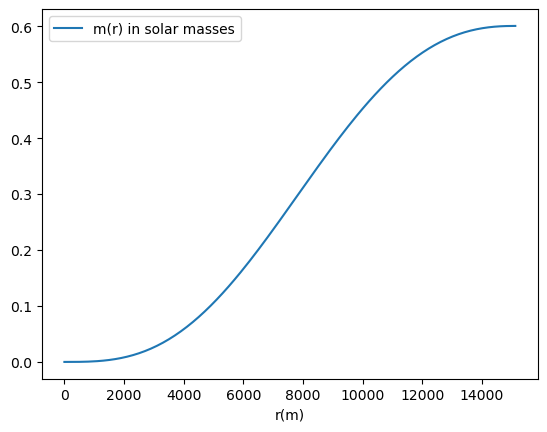

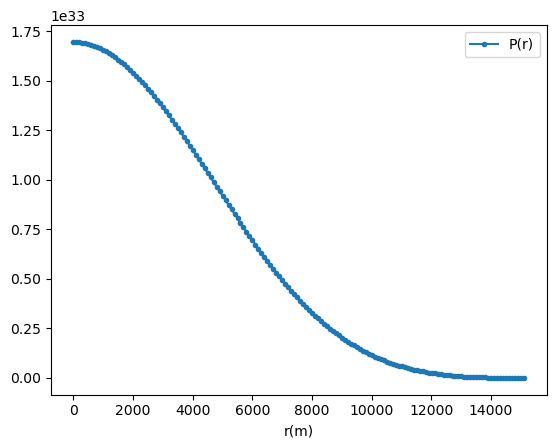

In [16]:
import matplotlib.pyplot as plt
from scipy.integrate import odeint

#parameters
gamma = 5/3
K = 5380.3
rho_c = 5e+17
p_c = K * (rho_c)**gamma

#initial conditions
r0 = 1e-4
m0 = (4/3) * math.pi * rho_c * (r0**3)
p0 = p_c
phi0 = np.nan #phi at r0 is not known

y0 = [m0, p0, phi0]

#input array of radius
r = np.linspace(r0, 1e5, 1000)

#solving the ode to find mass and pressure as a function of r 
sol = odeint(tov_equations, y0, r, args=(K, gamma), tfirst= True)
mr = sol[:,0]
pr = sol[:,1]
phii = sol[:,2]

#finding m* and r*
p_surface = np.nanmin(pr)
index = np.where(pr == p_surface)[0][0]
m_surface = mr[index]
radius_ns = r[index]
print('(m*,r*) = ({:.3E} kg,{:.2f} km)\n'.format(m_surface, radius_ns/1000))

#plotting
plt.plot(r, mr/2e30, label = 'm(r) in solar masses')
plt.xlabel('r(m)')
plt.legend()
plt.show()

plt.plot(r, pr,'.-', label = 'P(r)')
plt.legend()
plt.xlabel('r(m)')
plt.show()

/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/460949516.py:6: RuntimeWarning: divide by zero encountered in log
  lapse_sm = np.exp(np.log(1 - 2*G*m_surface/(r_sm * c**2)))


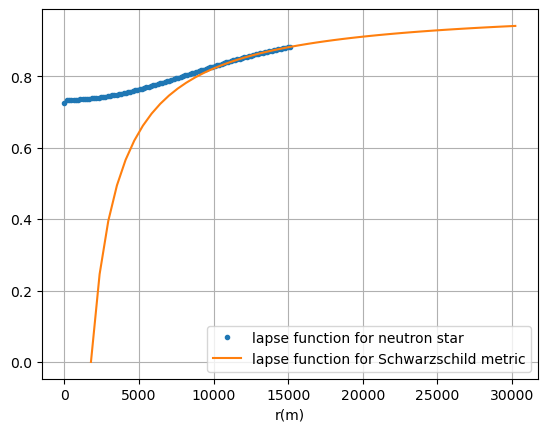

In [17]:
#problem 2

rs = 2*G*m_surface/(c**2)
phi_surface = 0.5 * np.log(1 - rs/radius_ns)
r_sm = np.linspace(rs, 2* radius_ns, 50)
lapse_sm = np.exp(np.log(1 - 2*G*m_surface/(r_sm * c**2)))

r2 = np.linspace(radius_ns, r0, 100)
y_intial = [m_surface, p_surface, phi_surface]

sol2 = odeint(tov_equations, y_intial, r2, args = (K, gamma), tfirst= True)
phi_r = sol2[:,2]
lapse_ns = np.exp(2*phi_r)

plt.plot(r2, lapse_ns,'.', label = 'lapse function for neutron star')
plt.plot(r_sm, lapse_sm,'-', label = 'lapse function for Schwarzschild metric')
plt.legend()
plt.grid()
plt.xlabel('r(m)')
plt.show()

<a id="sec5"></a>
## Ex 4A: Non-linear ODE with chaotic behavior: Lorenz equations

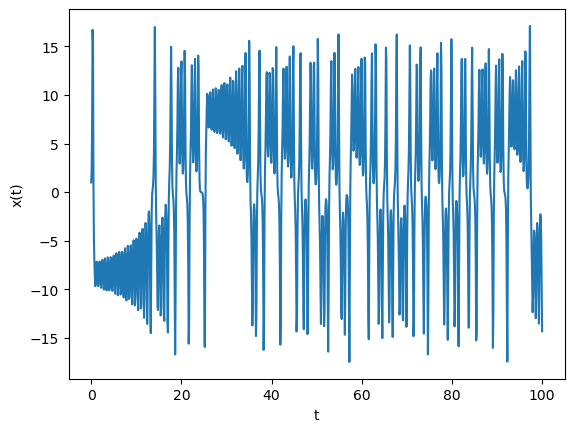

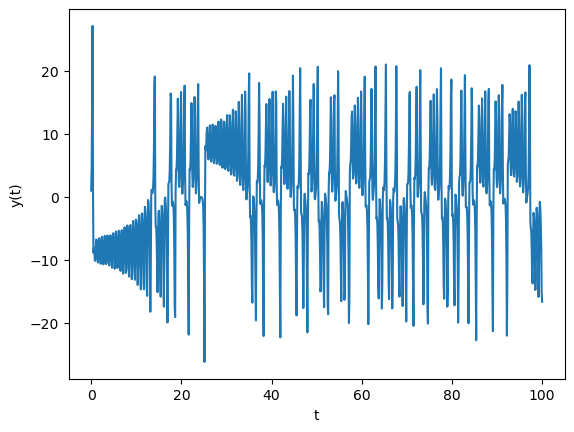

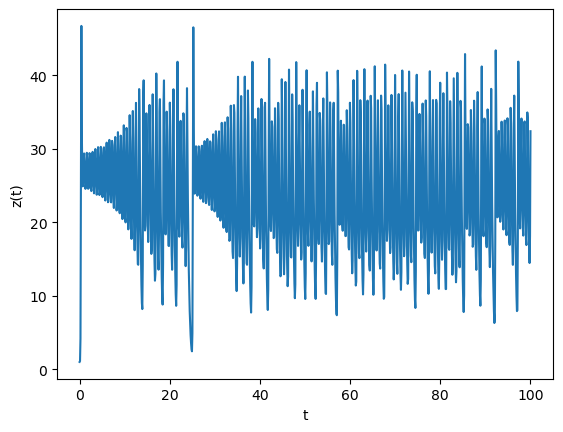

In [18]:
import numpy as np 
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def lorenz(a, t, rho, sigma, beta):
    '''helper function for odeint containing lorenz equations'''
    x, y, z = a
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x*y - beta * z
    return [dxdt, dydt, dzdt]

#parameters
rho = 28
sigma = 10
beta = 8.0/3.0

#initial conditions
t0 = 0
x0 = y0 = z0 = 1
a0 = [x0, y0, z0]

#input time array
t = np.linspace(t0,100, 1000)

#computing the solution
res = odeint(lorenz, a0, t, args = (rho, sigma, beta))
xt = res[:,0]
yt = res[:,1]
zt = res[:,2]

#plotting
plt.plot(t, xt)
plt.ylabel('x(t)')
plt.xlabel('t')
plt.show()

plt.plot(t, yt)
plt.xlabel('t')
plt.ylabel('y(t)')
plt.show()

plt.plot(t, zt)
plt.xlabel('t')
plt.ylabel('z(t)')
plt.show()

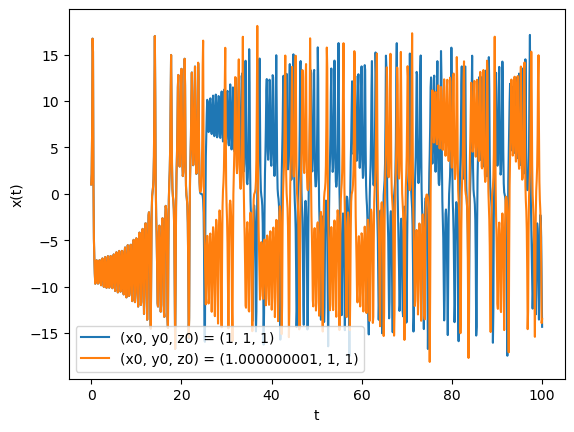

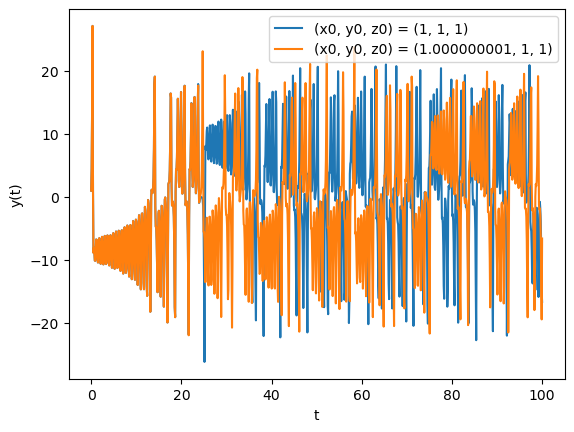

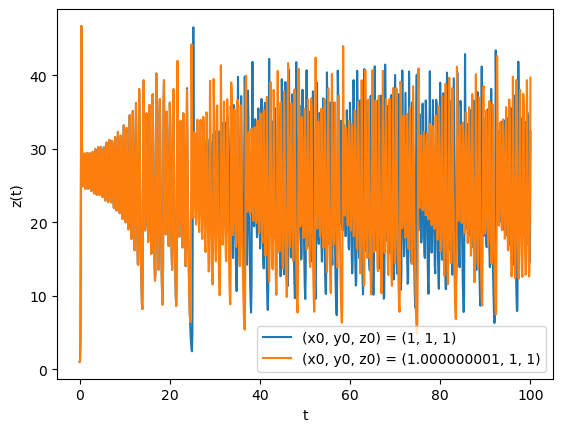

In [19]:
#problem2

#initial conditions
x02 = 1 + 1e-9
y02 = z02 = 1
a02 = [x02, y02, z02]

#computing the solutions
res2 = odeint(lorenz, a02, t, args = (rho, sigma, beta))
xt2 = res2[:,0]
yt2 = res2[:,1]
zt2 = res2[:,2]

#plotting
plt.plot(t, xt, label = '(x0, y0, z0) = ({}, {}, {})'.format(x0,y0,z0))
plt.plot(t, xt2, label = '(x0, y0, z0) = ({}, {}, {})'.format(x02, y02, z02))
plt.ylabel('x(t)')
plt.xlabel('t')
plt.legend()
plt.show()

plt.plot(t, yt, label = '(x0, y0, z0) = ({}, {}, {})'.format(x0,y0,z0))
plt.plot(t, yt2, label = '(x0, y0, z0) = ({}, {}, {})'.format(x02, y02, z02))
plt.xlabel('t')
plt.ylabel('y(t)')
plt.legend()
plt.show()

plt.plot(t, zt, label = '(x0, y0, z0) = ({}, {}, {})'.format(x0,y0,z0))
plt.plot(t, zt2, label = '(x0, y0, z0) = ({}, {}, {})'.format(x02, y02, z02))
plt.xlabel('t')
plt.ylabel('z(t)')
plt.legend()
plt.show()

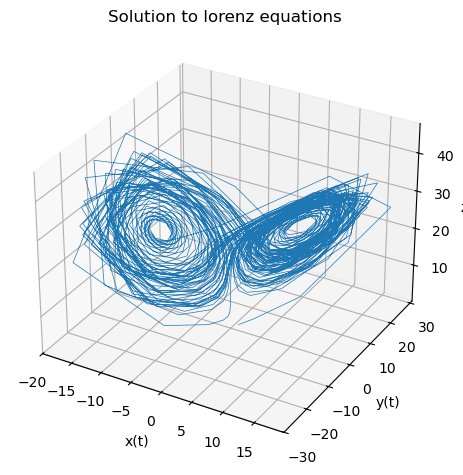

In [20]:
#problem 3: 3D plot
from mpl_toolkits import mplot3d

fig = plt.figure()
ax = plt.axes(projection = '3d')
plot = ax.plot3D(xt,yt,zt,linewidth=0.5)
ax.set_title('Solution to lorenz equations')
ax.set_xlabel('x(t)')
ax.set_ylabel('y(t)')
ax.set_zlabel('z(t)')
plt.tight_layout()
plt.show()

/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/539911861.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


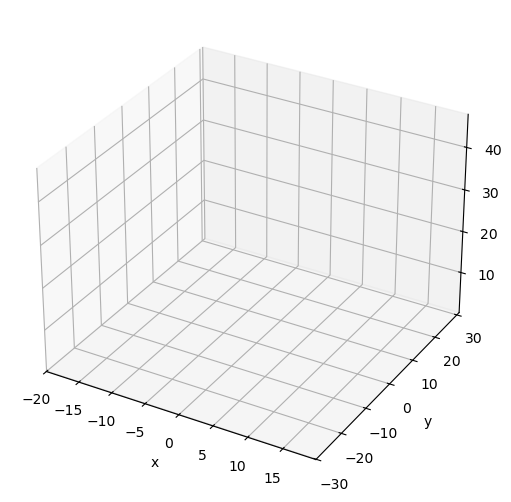

In [ ]:
#problem 4: animation
'''ref: https://cs.marlboro.college/cours/spring2018/jims_tutorials/computational_science/apr9.attachments/lorenz_attractor.html'''

import matplotlib.animation as animation

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1], projection='3d')
line, = ax.plot3D(xt, yt, zt, 'r-', linewidth=0.8)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.tight_layout()

def init():
    line.set_data([], [])
    line.set_3d_properties([])
    return line,

def update(num):
    line.set_data(xt[:num], yt[:num])
    line.set_3d_properties(zt[:num])
    fig.canvas.draw()
    return line,

ani = animation.FuncAnimation(fig, update, init_func=init, frames=len(t), blit=True)
plt.show()
ani.save('output/Lorenz_attractor.mp4', fps=50, extra_args=['-vcodec', 'libx264'])

<a id="sec6"></a>
## Ex 4B: Stochastic ODE: Langevin equation

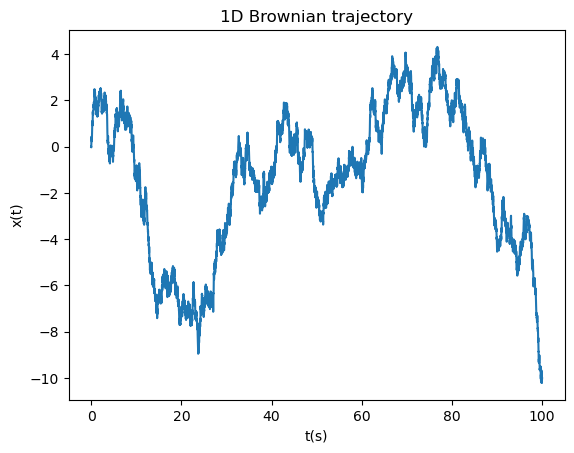

In [22]:
import numpy as np 
import matplotlib.pyplot as plt

def single_brownian(t, x0):
    '''Returns the trajectory of a single particle in 1d'''
    steps = t.shape[0]
    dt = t[1] - t[0]
    x = np.empty(steps)
    x[0] = x0
    for i in range(1, steps):
        x[i] = x[i-1] + np.random.randn() * np.sqrt(dt)
    return x

#Input time array, initial x, calling the function
t = np.arange(0, 100.01, 0.01)
x0 = 0
xt_brownian = single_brownian(t,0)

""" Each time we run this code we get a different trajectory. 
Thus the solution has intrinsic randomness and it is stochastic """

#Plotting
plt.plot(t, xt_brownian)
plt.xlabel('t(s)')
plt.ylabel('x(t)')
plt.title("1D Brownian trajectory")
plt.show()

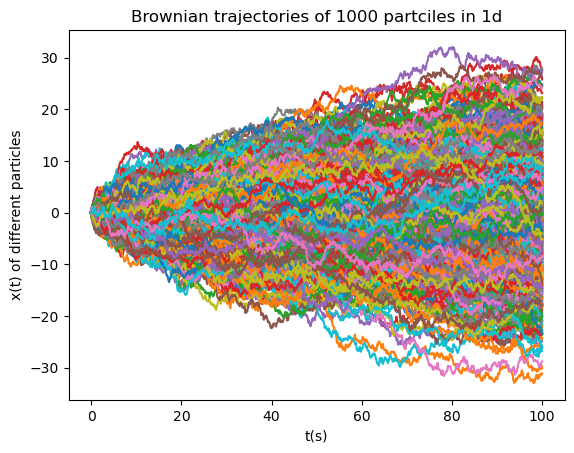

In [23]:
import numpy as np 
import matplotlib.pyplot as plt

def multi_brownian(t, x0):
    '''Returns the trajectories of a arbitrary number of particles in 1d'''
    steps = t.shape[0]
    dt = t[1] - t[0]
    num_particles = x0.shape[0]
    x = np.zeros((steps, num_particles))
    x[0] = x0
    for i in range(1, steps):
        x[i] = x[i-1] + np.random.randn(num_particles) * np.sqrt(dt)
    return x

stepsize = 0.1
t = np.arange(0, 100 + stepsize, stepsize)
n = 1000
x0 = np.zeros(n)
trajectories = multi_brownian(t,x0)

plt.plot(t, trajectories)
plt.xlabel('t(s)')
plt.ylabel('x(t) of different particles')
plt.title("Brownian trajectories of {} partciles in 1d".format(n))
plt.show()


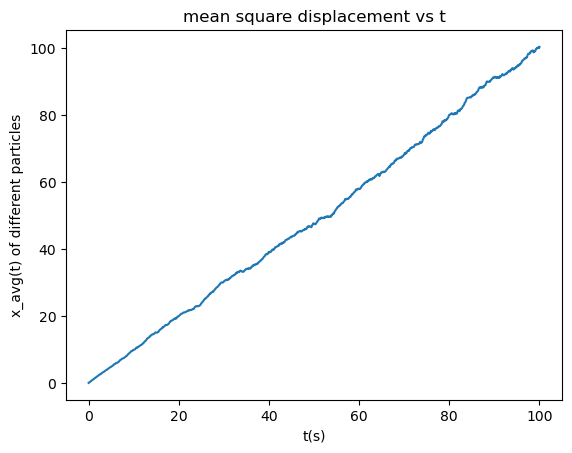

In [24]:
#Finding mean square displacement (msd) as function of t
disp_square = (trajectories - x0)**2
xmsd = np.mean(disp_square, axis = 1)

plt.plot(t, xmsd)
plt.xlabel('t(s)')
plt.ylabel('x_avg(t) of different particles')
plt.title("mean square displacement vs t")
plt.show()

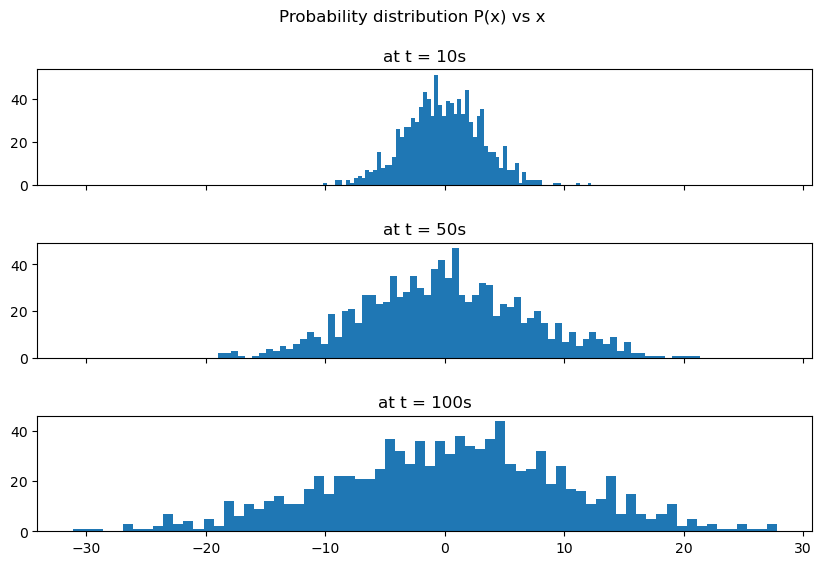

In [25]:
fig, ax = plt.subplots(3, sharex = True, figsize = (10,6))
fig.suptitle("Probability distribution P(x) vs x")
plt.subplots_adjust(hspace = 0.5)

#probability distribution P(x) of x(t=10)
ax[0].hist(trajectories[np.where(t == 10)[0][0]], bins = 70)
ax[0].set_title('at t = 10s')

#probability distribution P(x) of x(t=50)
ax[1].hist(trajectories[np.where(t == 50)[0][0]], bins = 70)
ax[1].set_title('at t = 50s')

#probability distribution P(x) of x(t=100)
ax[2].hist(trajectories[np.where(t == 100)[0][0]], bins = 70)
ax[2].set_title('at t = 100s')
plt.show()


<a id="sec7"></a>
## Ex 5: Two-point boundary value problems: The shooting method

In [26]:
import numpy as np 
import math
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.misc import derivative

def shooting_1d(x, b1_array, b2, func, func_params_tuple,  initial_guess = 0, maxI = 10):
    """
    Function to compute solutions of N-coupled first order ODEs. 
    Here the boundary value at second point is a scalar (hence 1d).
    Args:
        x: input numpy array with starting point x1 and end point x2
        b1_array: a list of boundary values at x1
        b2: boundary value at x2
        func: callable(t, y, ...) by 'odeint'
        func_params_tuple: tuple containing the parameters to be passed to func
        initial_guess: value guessed for the free parameter at x1
        maxI = maximum number of iterations allowed
    Returns:
        a list of solutions to variables contained in b1_array + variable corresponding to b2
    """

    def discrep(a):
        '''Function to find the discrepancy at the boundary for initial value a'''
        state1 = b1_array + [a]
        res = odeint(func, state1, x, args = func_params_tuple, tfirst= True)
        discrep = res[:,-1][-1] - b2
        return discrep

    a = initial_guess 
    i = 0
    while abs(discrep(a)) > 1e-10 and i < 10:
        a_next = a - discrep(a)/derivative(discrep,a, dx=0.001)
        a = a_next
        i += 1
    if i == maxI:
        print("newton-raphson method not working")

    state_finalvalue = b1_array + [a]
    sol = odeint(func, state_finalvalue, x, args = func_params_tuple, tfirst= True)
    return sol


In [27]:
#constants
G = 6.67e-11
c = 3e+8

#parameters
gamma = 5/3
K = 5380.3
rho_c = 5e+17
p_c = K * (rho_c)**gamma

radius_ns = 14000

#boundaries and input array
r1 = 1e-3
r2 = radius_ns #get neutron star radius from Ex. 3A
r = np.linspace(r1, r2, 100)

#boundary conditions
m1 = (4/3) * math.pi * rho_c * (r1**3)
p1 = p_c
phi2 = 0.5 * np.log(1 - 2*G*m_surface/(radius_ns * c**2)) 
y1 = [m1, p1]
y2 = phi2

#solving the ode using shooting method
soln = shooting_1d(r, y1, y2, tov_equations, (K, gamma))
mr = soln[:,0]
pr = soln[:,1]
phi_r = soln[:,2]
lapse_ns = np.exp(2*phi_r)

/var/folders/j_/1dyfcfg14tvdtldq4j6pqd640000gn/T/ipykernel_26506/757936331.py:33: DeprecationWarning: scipy.misc.derivative is deprecated in SciPy v1.10.0; and will be completely removed in SciPy v1.12.0. You may consider using findiff: https://github.com/maroba/findiff or numdifftools: https://github.com/pbrod/numdifftools
  a_next = a - discrep(a)/derivative(discrep,a, dx=0.001)


In [28]:
(7.7e22*3/(4*np.pi*1e17))**(1/3)

56.85919480859007

In [29]:
r[:5], mr[:5]/5.9e24

(array([1.00000000e-03, 1.41415131e+02, 2.82829263e+02, 4.24243394e+02,
        5.65657525e+02]),
 array([3.54982221e-16, 1.00373676e+00, 8.02568247e+00, 2.70633873e+01,
        6.40732442e+01]))

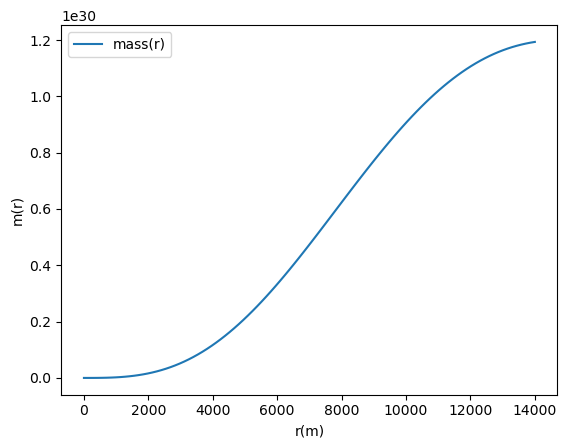

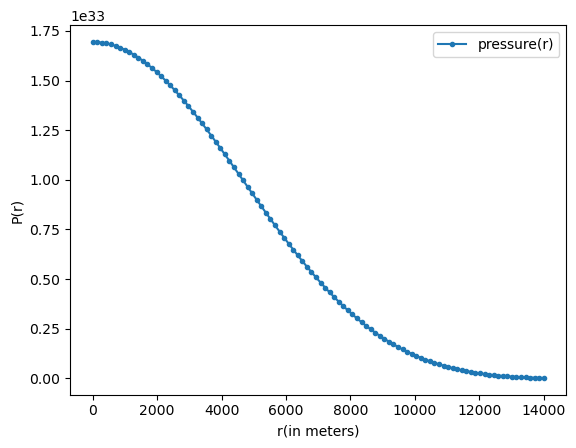

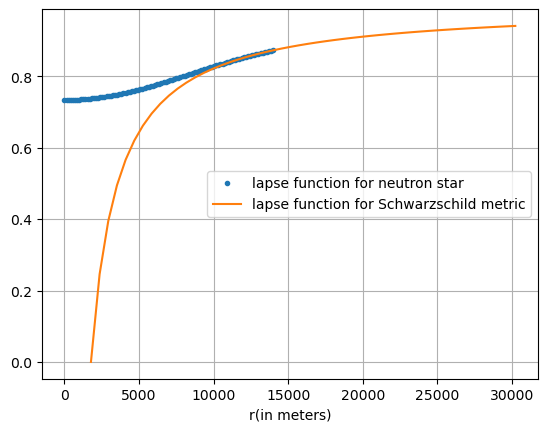

In [30]:
#plotting
plt.plot(r, mr, label = 'mass(r)')
plt.xlabel('r(m)')
plt.legend()
plt.ylabel('m(r)')
plt.show()

plt.plot(r, pr,'.-', label = 'pressure(r)')
plt.legend()
plt.xlabel('r(in meters)')
plt.ylabel('P(r)')
plt.show()

plt.plot(r, lapse_ns,'.', label = 'lapse function for neutron star')
plt.plot(r_sm, lapse_sm,'-', label = 'lapse function for Schwarzschild metric')
plt.legend(loc = 'center right')
plt.grid()
plt.xlabel('r(in meters)')
plt.show()

<a id="sec8"></a>
## Ex 6: Partial Differential Equations

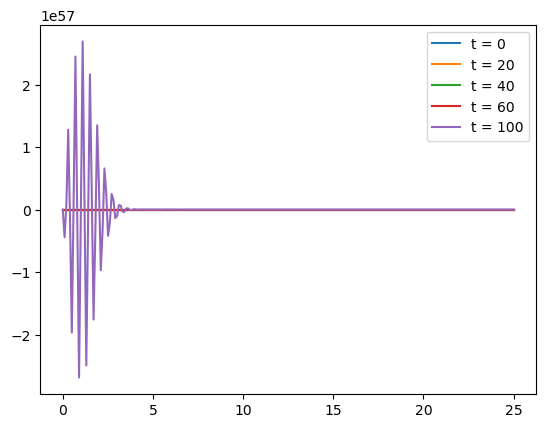

In [31]:
# %matplotlib notebook

import numpy as np 
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

def advec_ftcs(t, x, init_cond, v):
    xdim = x.shape[0]
    tdim = t.shape[0]
    dt = t[1] - t[0]
    dx = x[1] - x[0]
    u = np.zeros((tdim, xdim))
    u[0,:] = init_cond
    for n in range(tdim-1):
        for j in range(1, xdim-1):
            u[n+1,j] = -v * dt/(2*dx) * (u[n,j+1] - u[n,j-1]) + u[n,j]
    return u

#parameters and initial conditions
v = 1.0
a = 5
x = np.linspace(0,25, 250)
uxt0 = np.exp(-(x-a)**2)
t = np.linspace(0,100, 200)

#solve the PDE
sol = advec_ftcs(t,x,uxt0,v)

#plotting at different instances of time
time = [0,20,40,60,100]
for instance in time:
    plt.plot(x, sol[instance,:], label = 't = {}'.format(instance))
plt.legend()
plt.show()

In [32]:
import numpy as np 
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

def init_cond(x):
    a = 5
    return np.exp(-(x-a)**2)

def make_grid(t_range, x_range, v, cfl, N):
    x_data, dx = np.linspace(x_range[0], x_range[1], N, retstep=True)
    dt = abs(cfl * dx/v)
    time = np.arange(t_range[0], t_range[1], dt)
    return time, x_data

def advec_updownwind(t, x, init_values, v):
    
    dx = x[1] - x[0]
    dt = t[1] - t[0]
    xdim = x.shape[0]
    tdim = t.shape[0]
    u = np.zeros((tdim, xdim))
    u[0,:] = init_values
    u[:,0] = u[:,-1] #periodic boundary condition
    
    for n in range(tdim-1):
        for j in range(0, xdim):
            if v>0:
                u[n+1,j] = -v * dt/dx * (u[n,j] - u[n,j-1]) + u[n,j]
            elif v<0:
                u[n+1,j] = -v * dt/dx * (u[n,j+1] - u[n,j]) + u[n,j]

    return u

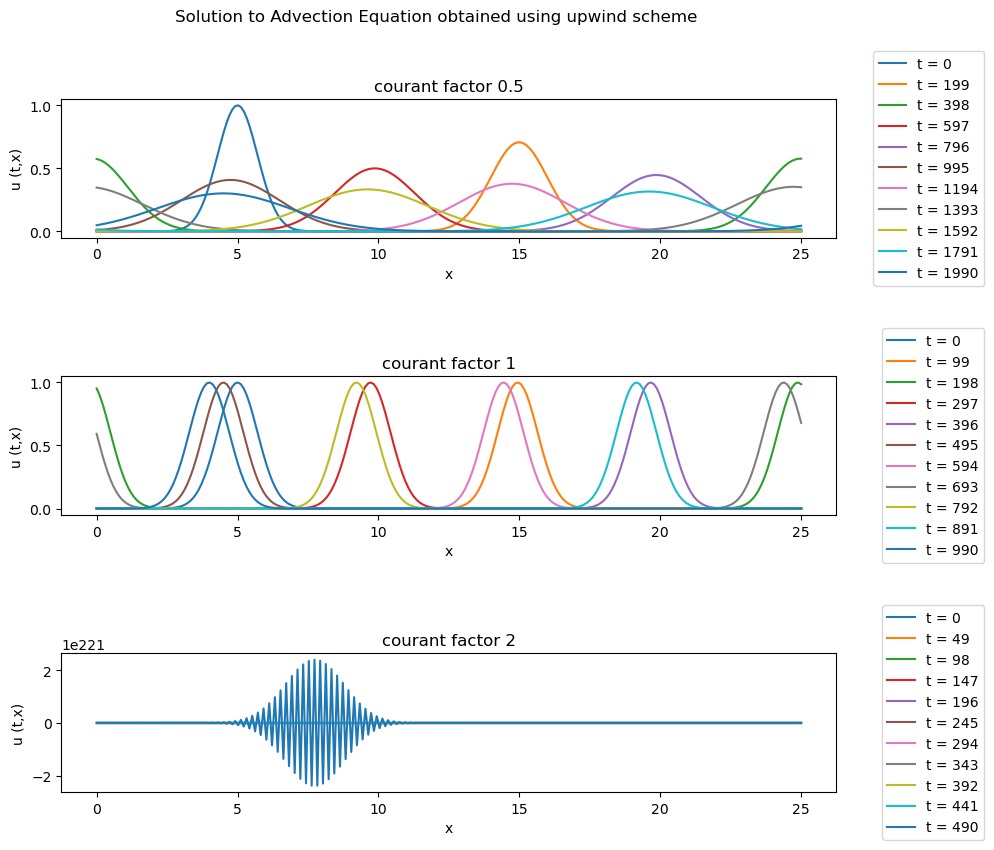

In [33]:
#parameters
v = 1.0
xmin = 0
xmax = 25
tmin = 0
tmax = 100
N = 250

#courant factors
cfl = [0.5, 1, 2]

#computing the solution and plotting
fig, ax = plt.subplots(len(cfl), figsize=(10, 9))
time = [0,100,200,300,400]

for i in range(len(cfl)):
    t,x = make_grid((tmin, tmax), (xmin, xmax), v, cfl[i], N)
    sol = advec_updownwind(t,x,init_cond(x),v)
    instances = np.arange(0, len(t), len(t)//10)
    for inst in instances:
        ax[i].plot(x, sol[inst,:], label = 't = {}'.format(inst))
        ax[i].set_xlabel('x')
        ax[i].set_ylabel('u (t,x)')
        ax[i].set_title("courant factor {}". format(cfl[i]))
        ax[i].legend(loc = 'right', bbox_to_anchor=(1.2, 0.5))

plt.subplots_adjust(hspace = 1)
fig.suptitle("Solution to Advection Equation obtained using upwind scheme")
plt.show()


<a id="sec9"></a>
## Ex 7A: Fast Fourier transform (FFT)

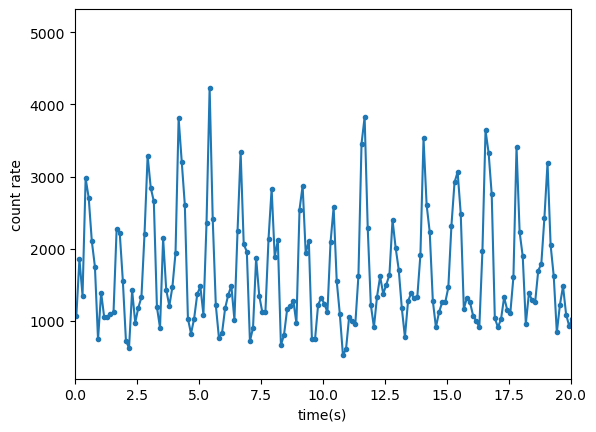

In [34]:
import numpy as np 
from scipy import fftpack, stats, signal
import matplotlib.pyplot as plt

time, countrate= np.loadtxt('data/extracted_lightcurve_HerX-1.dat', unpack=True)

plt.plot(time, countrate, '.-')
plt.xlabel("time(s)")
plt.ylabel('count rate')
plt.xlim(0,20)
plt.show()

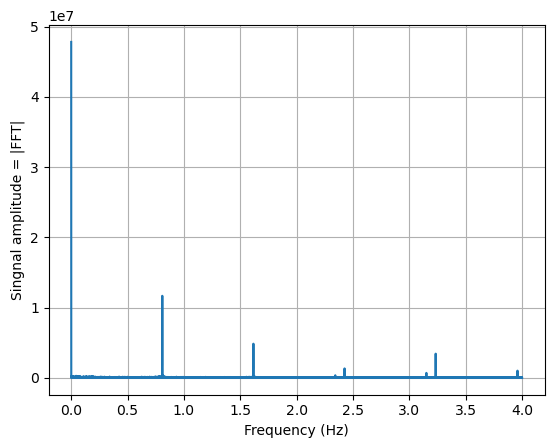

In [35]:
N = len(countrate)
dt = np.median(np.diff(time))

freqs = fftpack.fftfreq(N, d=dt)[:N//2] #take positive frequency values only
fft_lightcurve = fftpack.fft(countrate)[:N//2]
amplitude = np.abs(fft_lightcurve)
'''Note: fftfreq(N)/dt = fftfreq(N) * sampling rate = fftpack.fftfreq(N, d=dt)'''

plt.plot(freqs, amplitude, '-')
plt.xlabel("Frequency (Hz)")
plt.ylabel('Singnal amplitude = |FFT|')
plt.grid()
plt.show()

In [36]:
peaks, _ = signal.find_peaks(amplitude, threshold=5e5)
periodic_signals = freqs[peaks]
min_freq = periodic_signals[0]
pulsar_period = 1.0/min_freq

print('spin period of the pulsar is {:.2f} secs'.format(pulsar_period))
print('The periodic signals have frequencies (in Hz): {}'.format(periodic_signals))
var = np.rint(periodic_signals[1:]/min_freq) 
print('For f = {:.3f}, they become {}'.format(min_freq, list(map('{:01.0f}f'.format,var))))

spin period of the pulsar is 1.24 secs
The periodic signals have frequencies (in Hz): [0.80816901 1.61633803 2.42478873 3.23295775 3.95887324]
For f = 0.808, they become ['2f', '3f', '4f', '5f']


<a id="sec10"></a>
## Ex 7B: Power spectrum estimation using FFT

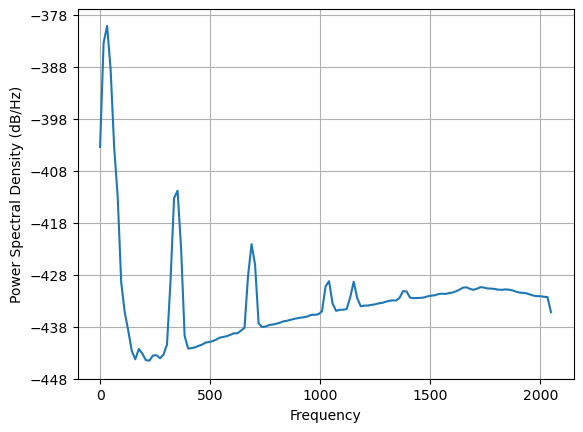

In [37]:
import numpy as np 
from scipy import signal
import matplotlib.pyplot as plt

strain = np.loadtxt('data/L1-STRAIN_4096Hz-815045078-256.txt')
plt.psd(strain, Fs = 4096)
plt.show()

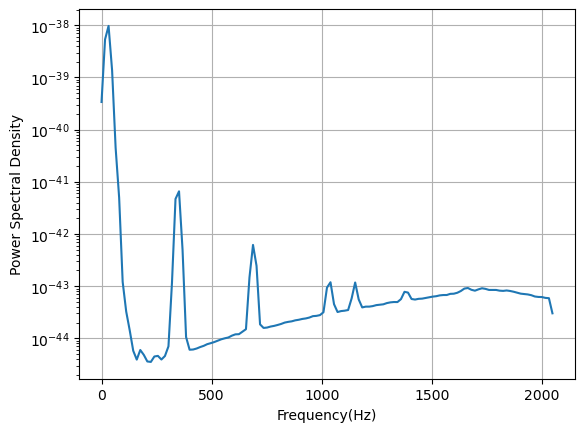

In [38]:
# Method 2
f, psd = signal.welch(strain, fs = 4096)
plt.semilogy(f, psd)
plt.xlabel('Frequency(Hz)')
plt.ylabel('Power Spectral Density')
plt.grid()
plt.show()

<a id="sec11"></a>
## Ex 7C: Time-frequency signal detection methods

In [39]:
import numpy as np 
import matplotlib.pyplot as plt

arrival_times = np.loadtxt('data/4U1636-536_LC-extract.dat')


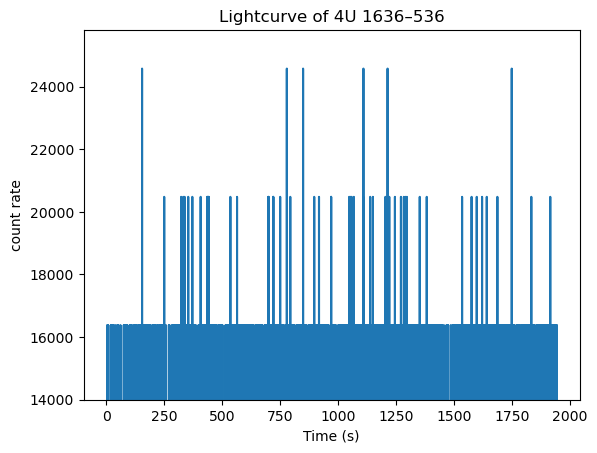

In [40]:
# Define timebins
sampling_rate = 4096.0 #in Hz
binsize = 1.0/sampling_rate
tbins = np.arange(arrival_times[0], arrival_times[-1], binsize)

# Make histogoram
counts, bins = np.histogram(arrival_times, bins=tbins)
bins = (bins[1:] + bins[:-1])/2

countrate = counts/binsize

# Plot
plt.plot(bins, countrate)
plt.title('Lightcurve of 4U 1636–536')
plt.xlabel('Time (s)')
plt.ylabel('count rate')
plt.ylim(bottom = 14000)

plt.show()

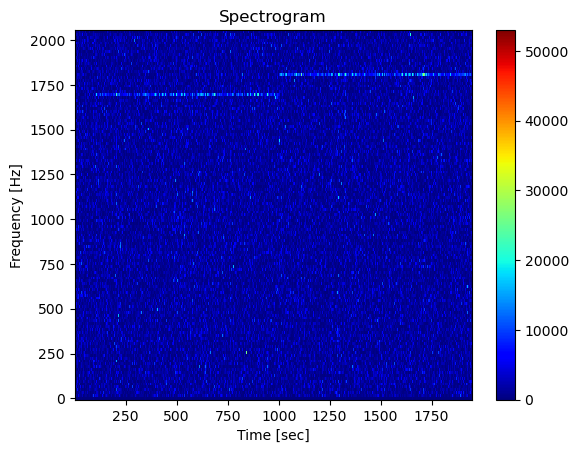

In [41]:
from scipy import signal

freqs, t, Pxx= signal.spectrogram(countrate, fs=sampling_rate)
# index = np.where((freqs >= 250) & (freqs <= 1250))
# freqs = freqs[(index)]
# Pxx = Pxx[(index)]
plt.pcolormesh(t, freqs, Pxx, cmap = 'jet')
plt.title("Spectrogram")
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar()
# plt.clim(1000,5000)
plt.show()

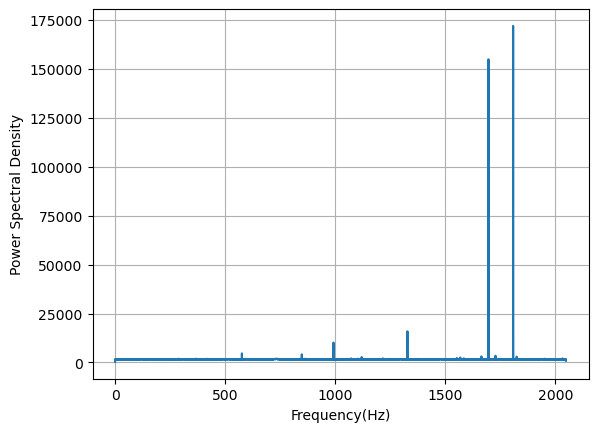

In [42]:
f, psd = signal.welch(countrate, fs = sampling_rate, nperseg = 2**14)
plt.plot(f, psd)
plt.xlabel('Frequency(Hz)')
plt.ylabel('Power Spectral Density')
# plt.xlim(250, 1250)
plt.grid()
plt.show()

<a id="sec12"></a>
## Ex D: Computing correlations using FFT: Matched filtering

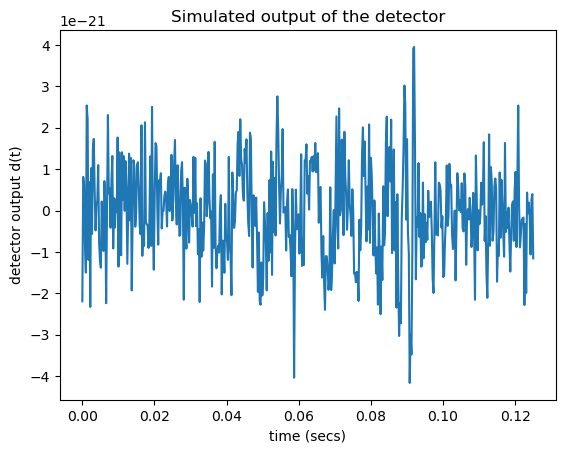

In [43]:
import numpy as np 
import matplotlib.pyplot as plt

#load data
time, xt = np.loadtxt('data/mock_gw_data.dat', unpack = True)

#plot data
plt.plot(time, xt)
plt.xlabel('time (secs)')
plt.ylabel('detector output d(t)')
plt.title('Simulated output of the detector')
plt.show()

In [44]:
from scipy.integrate import odeint, simps
from scipy import optimize

def make_BBCtemplate(t,m, muBYm, ta=0, v0 = 0.3, phi0 = 0):
    '''
    Function to compute the gravitational-wave signal from a black hole binary
    Args:
        t: input time array in secs.
        m: sum of masses of the coalescencing black holes (m1 + m2) in solar units.
        muBYm: the ratio of reduced mass to sum of masses in solar units.
        ta: time of arrival of the signal in secs
        v0: initial value of v(check the problem sheet for the definition)
        phi0: initial phase value
    Returns:
        ndarray of GW signal over the given time.
    '''
    
    def inspiral_vphi(t, y, m, mu):
        '''
        Helper fuction to be used by odeint
        '''
        v, phi = y
        dv_dt = (32/5) * (mu/m**2) * (v**9)
        dphi_dt = (v**3)/m
        dydt = [dv_dt, dphi_dt]
        return dydt

    #constants
    G = 6.67e-11
    c = 3e+8
    Msun = 1.989e+30 * G/(c**3)

    #change units
    mu = muBYm * m * Msun
    m = m * Msun

    #intial conditions
    y0 = [v0, phi0]
    
    #initializing
    signal = np.zeros(len(t)) #set signal to be zero after the merger
    t_merger = 5*m**2/(256*mu*v0**8)
    t_signal = t[t < 0.99*t_merger]
    
    #compute the waveform
    sol = odeint(inspiral_vphi, y0, t_signal, args= (m, mu), tfirst= True, mxstep=5000, rtol=1e-8, atol=1e-10)
    vt = sol[:,0]
    phi_t = sol[:, 1]
    A_t = (4*mu/m) * (vt**2)
    signal[:t_signal.shape[0]] = A_t * np.cos(phi_t)

    #shifting the signal to accomodate time of arrival
    index_arrival = np.where(t>=ta)[0][0]
    signal = np.roll(signal,index_arrival)
    
    return signal


def correlation_BBC(params,t, xt, sign = 1):
    '''Function to find the correlation between detector output x(t) 
    and computed GW signal h(t) [see the problem for definition]
    Args:
        params: parameters (in order) - sum of masses m (solar units), ratio of reduced mass to 
                 sum of masses mu/m, time delay tau.
        t: time series
        xt: measured/simulated detector output
        sign: should be -1 while using scipy optimization
    Returns:
       sign * corr_tau: correlation with given parameters multiplied by sign.    
    '''
    m = params[0]
    muBYm = params[1]
    tau = params[2]
    #Following is based on the definitions found in the problem
    sigma = 1e-21
    ht = make_BBCtemplate(t, m, muBYm)
    htau = make_BBCtemplate(t, m, muBYm, tau)
    norm = np.sqrt(simps(ht**2, t))/sigma
    integrand = xt * htau/norm
    corr_tau = simps(integrand, t)
    
    return sign * corr_tau


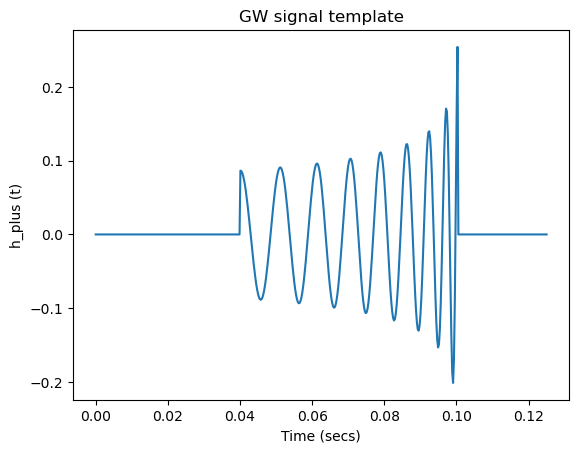

In [45]:
#checking the template
sig = make_BBCtemplate(time,10, 0.24, 0.04)
plt.plot(time, sig)
plt.xlabel('Time (secs)')
plt.ylabel('h_plus (t)')
plt.title('GW signal template')
plt.show()

In [46]:
#estimating the parameters
bounds = [(5, 15), (0.2, 0.25), (time[0], time[-1])]
iterations = 5
res = np.zeros((iterations,3))
for i in range(iterations):
    res[i,:] = optimize.differential_evolution(correlation_BBC, bounds, args=(time, xt, -1))['x']
parameters = np.mean(res, axis = 0)
print("The estimated parameters: [m  mu/m  tau] = {}".format(parameters))

The estimated parameters: [m  mu/m  tau] = [10.41472815  0.22677559  0.02432723]


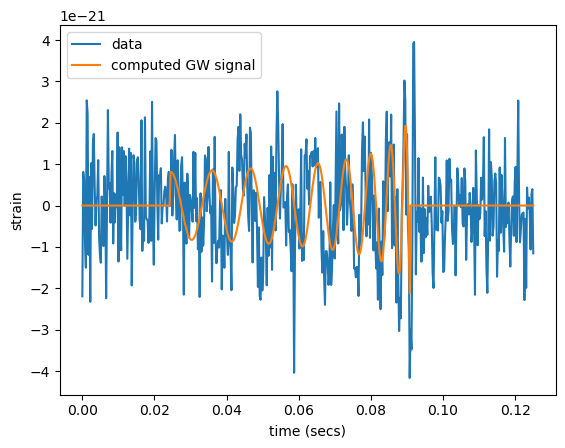

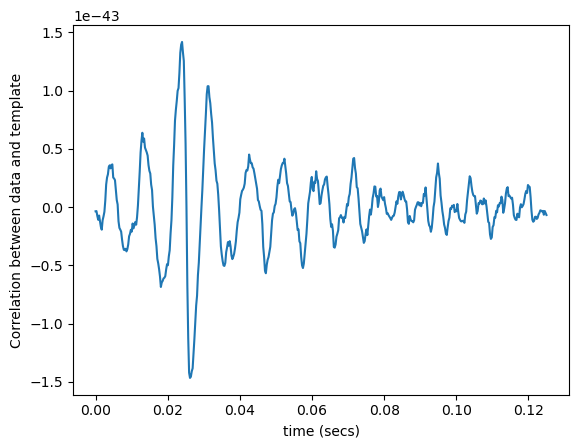

In [47]:
#Verifying the above result

#superimposing signal and template
lum_distance = 50 *(3.086e+22) #50Mpc in geometric units (this is just a guess)
mass = parameters[0] * 1474.07 #in geomtric units
factor = mass/lum_distance # m/D
signal = factor * make_BBCtemplate(time, parameters[0], parameters[1], parameters[2])
plt.plot(time, xt, label = 'data')
plt.plot(time, signal, label = 'computed GW signal')
plt.ylabel('strain')
plt.xlabel('time (secs)')
plt.legend()
plt.show()

#correlation function with estimated mass and mu/m
corr = np.zeros(len(time))
for i in range(len(time)):
    corr[i]= correlation_BBC([parameters[0], parameters[1], time[i]], time, xt)

plt.plot(time, corr)
plt.ylabel('Correlation between data and template')
plt.xlabel('time (secs)')
plt.show()